In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
%matplotlib qt

In [ ]:
# step-0: spread out some points at random
num_points = 50
R = 100
step_size = 0.01  # how much they move in each time step
N_dim = 1  # in how many dims are we working?
N_steps = 1000

np.random.seed(2)
pos = np.sort(R * np.random.random(num_points))
y = np.zeros_like(pos)

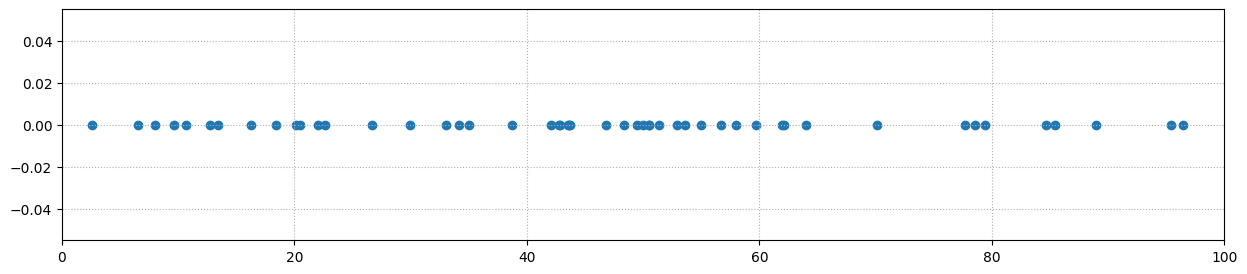

In [ ]:
def plot_positions(pos):
    fig, ax = plt.subplots(figsize=(15, 3))
    ax.scatter(pos, y)
    ax.grid(ls=":")
    ax.set_xlim(0, R)


plot_positions(pos)

In [ ]:
def compute_net_force(pos):
    F_net = np.zeros_like(pos)
    for i, posN in enumerate(pos):
        dist = pos - posN

        dist_left = dist[dist < 0]
        dist_right = dist[dist > 0]

        F_net[i] = np.sum(np.abs(1 / dist_left**N_dim)) - np.sum(
            np.abs(1 / dist_right**N_dim)
        )

    return F_net

In [ ]:
for step in tqdm(range(N_steps)):
    effective_step_size = step_size * (1 - step / (N_steps * 50))

    new_pos = pos + effective_step_size * compute_net_force(pos)
    new_pos = np.clip(new_pos, a_min=0, a_max=R)  # respect the boundaries

100%|██████████| 1000/1000 [00:00<00:00, 1676.49it/s]


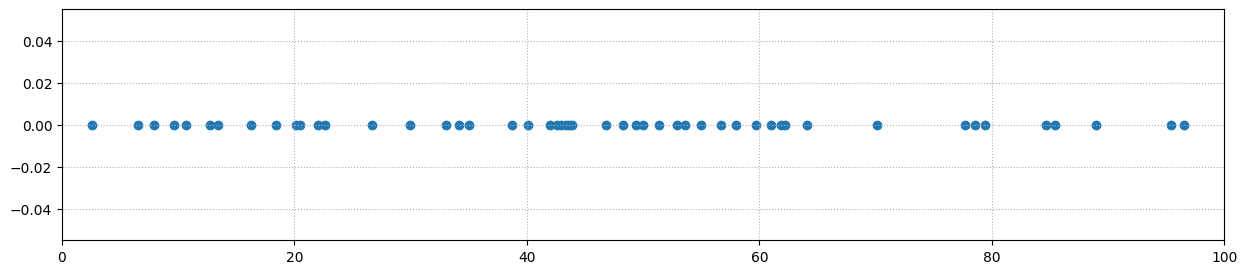

In [ ]:
plot_positions(new_pos)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# LEO parameters
num_points = 50
R_earth = 6371
altitude = 550
R = R_earth + altitude  # orbital radius = Earth radius + altitude

step_size = 0.01
N_dim = 2
N_steps = 1000

np.random.seed(2)

# evenly spaced angles around the circle
angles = np.linspace(0, 2 * np.pi, num_points, endpoint=False)

pos = np.vstack([R * np.cos(angles), R * np.sin(angles)]).T

In [ ]:
def plot_positions(pos):
    fig, ax = plt.subplots(figsize=(7, 7))

    # Earth
    earth = plt.Circle((0, 0), R_earth, color="blue", alpha=0.3)
    ax.add_patch(earth)

    # Orbit circle
    orbit = plt.Circle((0, 0), R, fill=False, ls="--")
    ax.add_patch(orbit)

    # Satellites
    ax.scatter(pos[:, 0], pos[:, 1], color="red")

    ax.set_aspect("equal")
    ax.grid(ls=":")
    ax.set_xlim(-R - 500, R + 500)
    ax.set_ylim(-R - 500, R + 500)

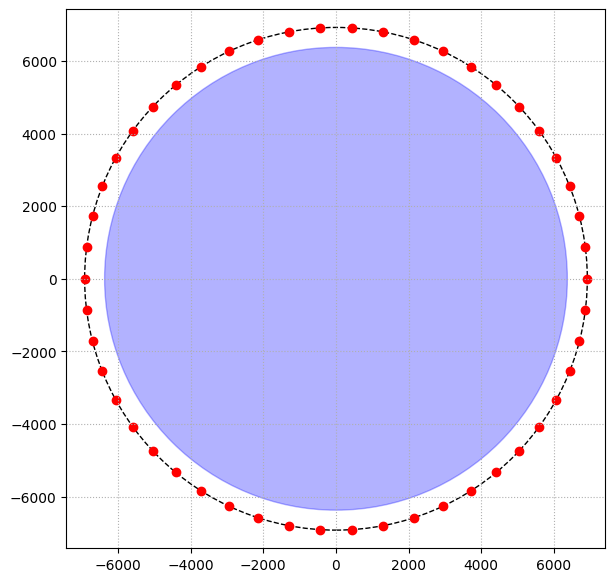

In [ ]:
plot_positions(pos)

In [ ]:
def compute_net_force(pos):
    F_net = np.zeros_like(pos)

    for i, p in enumerate(pos):
        dist_vec = pos - p

        mask = np.any(dist_vec != 0, axis=1)
        dist_vec = dist_vec[mask]

        dist = np.linalg.norm(dist_vec, axis=1)

        magnitudes = 1 / (dist**N_dim)

        directions = dist_vec / dist[:, None]

        F_net[i] = np.sum(magnitudes[:, None] * directions, axis=0)

    return F_net

In [ ]:
pos_current = pos.copy()

for step in tqdm(range(N_steps)):
    effective_step_size = step_size * (1 - step / (N_steps * 50))

    forces = compute_net_force(pos_current)
    new_pos = pos_current + effective_step_size * forces

    radii = np.linalg.norm(new_pos, axis=1)
    new_pos = (new_pos.T * (R / radii)).T

    pos_current = new_pos

100%|██████████| 1000/1000 [00:00<00:00, 3167.37it/s]


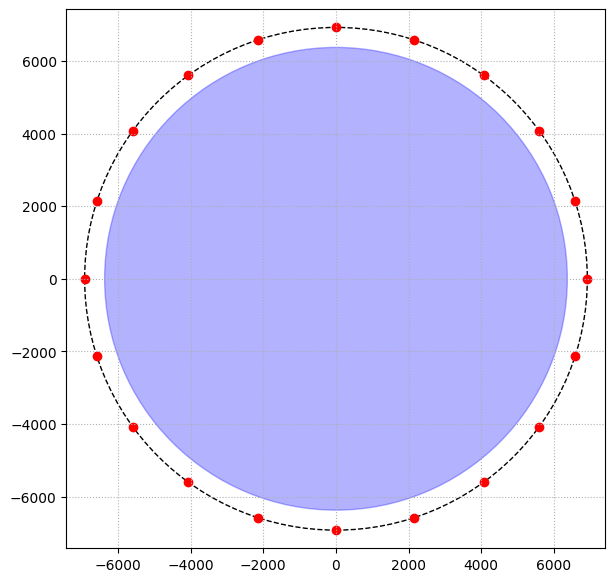

In [ ]:
plot_positions(pos_current)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D

# LEO parameters
num_points = 50
R_earth = 6371
altitude = 550
R = R_earth + altitude

step_size = 0.01
N_dim = 2
N_steps = 1000

np.random.seed(2)

# evenly spaced points using Fibonacci sphere
indices = np.arange(0, num_points, dtype=float) + 0.5
phi = np.arccos(1 - 2 * indices / num_points)
theta = np.pi * (1 + 5**0.5) * indices

x = R * np.sin(phi) * np.cos(theta)
y = R * np.sin(phi) * np.sin(theta)
z = R * np.cos(phi)

pos = np.vstack([x, y, z]).T

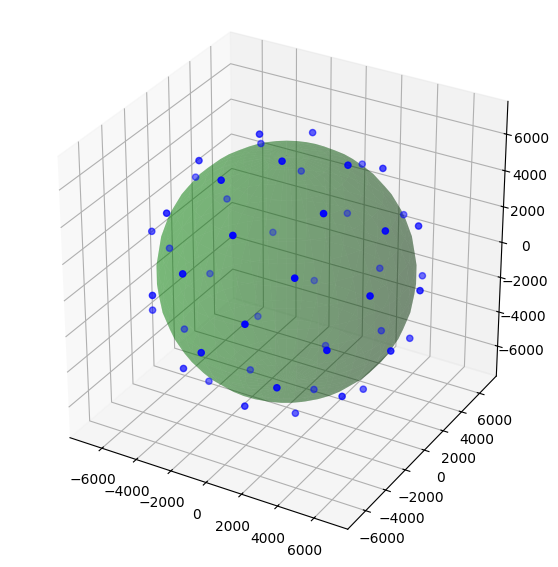

In [ ]:
def plot_positions_3d(pos):
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")

    # Satellites
    ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], color="blue")

    # Earth sphere
    u, v = np.mgrid[0 : 2 * np.pi : 40j, 0 : np.pi : 20j]
    xe = R_earth * np.cos(u) * np.sin(v)
    ye = R_earth * np.sin(u) * np.sin(v)
    ze = R_earth * np.cos(v)
    ax.plot_surface(xe, ye, ze, color="green", alpha=0.3)

    ax.set_box_aspect([1, 1, 1])
    plt.show()


plot_positions_3d(pos)

In [ ]:
def compute_net_force(pos):
    F_net = np.zeros_like(pos)

    for i, p in enumerate(pos):

        dist_vec = pos - p

        mask = np.any(dist_vec != 0, axis=1)

        dist_vec = dist_vec[mask]

        dist = np.linalg.norm(dist_vec, axis=1)

        magnitudes = 1 / (dist**N_dim)

        directions = dist_vec / dist[:, None]

        F_net[i] = np.sum(magnitudes[:, None] * directions, axis=0)

    return F_net

100%|██████████| 1000/1000 [00:01<00:00, 979.49it/s]


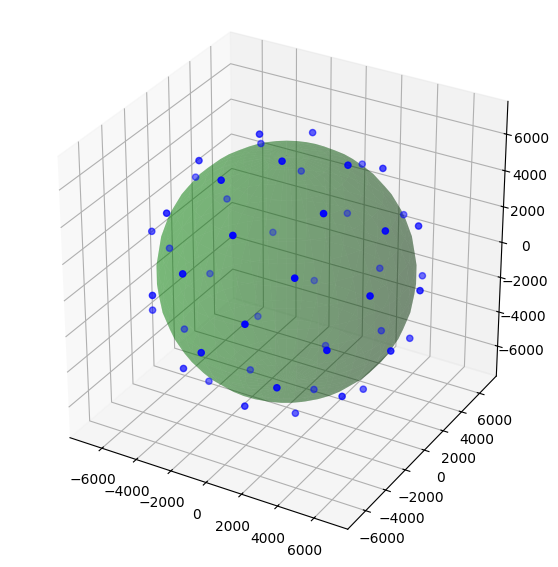

In [ ]:
pos_current = pos.copy()

for step in tqdm(range(N_steps)):
    effective_step_size = step_size * (1 - step / (N_steps * 50))

    forces = compute_net_force(pos_current)
    new_pos = pos_current + effective_step_size * forces

    radii = np.linalg.norm(new_pos, axis=1)
    new_pos = (new_pos.T * (R / radii)).T

    pos_current = new_pos


plot_positions_3d(pos_current)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import heapq
from matplotlib import animation

R_EARTH_KM = 6371.0

class Node:
    def __init__(self, id, type, pos3d=None):
        self.id = id
        self.type = type
        self.pos3d = pos3d


In [ ]:
def set_axes_equal(ax):

    limits = np.array([
        ax.get_xlim3d(),
        ax.get_ylim3d(),
        ax.get_zlim3d(),
    ])
    spans = limits[:,1] - limits[:,0]
    centers = np.mean(limits, axis=1)
    radius = 0.5 * max(spans)

    ax.set_xlim3d([centers[0] - radius, centers[0] + radius])
    ax.set_ylim3d([centers[1] - radius, centers[1] + radius])
    ax.set_zlim3d([centers[2] - radius, centers[2] + radius])

class Simulation:
    def __init__(self, shells, max_isl_km):

        self.shells = shells          # list of orbital shells
        self.max_isl_km = max_isl_km  # max link distance

        self.nodes = []
        self.graph = {}


        sat_id = 0
        for shell in shells:
            positions = self.generate_shell(
                shell["num_planes"],
                shell["sats_per_plane"],
                shell["altitude_km"],
                shell["inclination_deg"]
            )
            for pos in positions:
                self.nodes.append(Node(id=f"S{sat_id}", type="sat", pos3d=pos))
                sat_id += 1

        self._build_graph()


    
    def generate_shell(self, num_planes, sats_per_plane, altitude_km, inclination_deg, f=1):
        R = R_EARTH_KM + altitude_km
        inc = np.radians(inclination_deg)

        satellites = []

        for p in range(num_planes):
            RAAN = 2*np.pi * p / num_planes

            for k in range(sats_per_plane):
                # Walker Delta phasing
                theta = 2*np.pi * k / sats_per_plane + 2*np.pi * f * p / num_planes

                # Base circular orbit in equatorial plane
                x = R * np.cos(theta)
                y = R * np.sin(theta)
                z = 0

                # Inclination rotation (around x-axis)
                y_i = y * np.cos(inc) - z * np.sin(inc)
                z_i = y * np.sin(inc) + z * np.cos(inc)
                x_i = x

                # RAAN rotation (around z-axis)
                x_f = x_i * np.cos(RAAN) - y_i * np.sin(RAAN)
                y_f = x_i * np.sin(RAAN) + y_i * np.cos(RAAN)
                z_f = z_i


                satellites.append((x_f, y_f, z_f))

        return satellites



    
    def _build_graph(self):
        self.graph = {n.id: [] for n in self.nodes}

        for i, a in enumerate(self.nodes):
            for b in self.nodes[i+1:]:
                d = np.linalg.norm(np.array(a.pos3d) - np.array(b.pos3d))
                if d <= self.max_isl_km:
                    self.graph[a.id].append((b.id, d))
                    self.graph[b.id].append((a.id, d))





    
    def plot_topology_3d(self):
        fig = plt.figure(figsize=(10,10))
        ax = fig.add_subplot(111, projection='3d')

        # Earth
        u = np.linspace(0, 2*np.pi, 50)
        v = np.linspace(0, np.pi, 50)
        x = R_EARTH_KM * np.outer(np.cos(u), np.sin(v))
        y = R_EARTH_KM * np.outer(np.sin(u), np.sin(v))
        z = R_EARTH_KM * np.outer(np.ones_like(u), np.cos(v))
        ax.plot_surface(x, y, z, color="green", alpha=0.3)

        # Draw orbital rings for each shell
        theta = np.linspace(0, 2*np.pi, 200)

        for shell in self.shells:
            R = R_EARTH_KM + shell["altitude_km"]
            inc = np.radians(shell["inclination_deg"])

            for p in range(shell["num_planes"]):
                RAAN = 2*np.pi * p / shell["num_planes"]

                x0 = R * np.cos(theta)
                y0 = R * np.sin(theta)
                z0 = np.zeros_like(theta)

                y1 = y0 * np.cos(inc)
                z1 = y0 * np.sin(inc)
                x1 = x0

                x2 = x1*np.cos(RAAN) - y1*np.sin(RAAN)
                y2 = x1*np.sin(RAAN) + y1*np.cos(RAAN)
                z2 = z1

                ax.plot(x2, y2, z2, color='black', linewidth=0.9, alpha=0.5)

        # Satellites
        xs = [n.pos3d[0] for n in self.nodes]
        ys = [n.pos3d[1] for n in self.nodes]
        zs = [n.pos3d[2] for n in self.nodes]
        ax.scatter(xs, ys, zs, color='blue', s=20)



        set_axes_equal(ax)
        #ax.view_init(elev=70, azim=0) #top view
        #ax.view_init(elev=90, azim=0) #side view
        ax.view_init(elev=90, azim=90)



        plt.show()




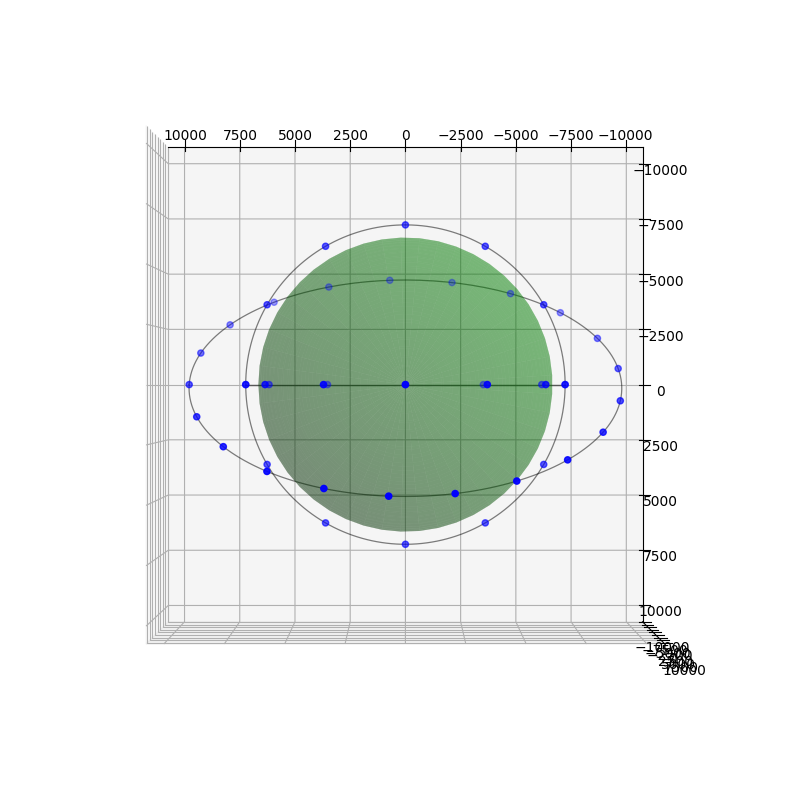

In [ ]:
shells = [
    { "num_planes": 1, "sats_per_plane": 12, "altitude_km": 550,  "inclination_deg": 60 }, # LEO
    { "num_planes": 1, "sats_per_plane": 21,  "altitude_km": 3000, "inclination_deg": 60 }, # MEO

    # Equatorial orbit (0° inclination)
    { "num_planes": 1, "sats_per_plane": 12, "altitude_km": 550, "inclination_deg": 0 },

    # Polar orbit (90° inclination)
    { "num_planes": 1, "sats_per_plane": 12, "altitude_km": 550, "inclination_deg": 90 }
]

sim = Simulation(shells=shells, max_isl_km=5000)



sim.plot_topology_3d()